In [1]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import mglearn
import tensorflow as tf

from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

np.random.seed(180)
tf.random.set_seed(180)

In [3]:
people = fetch_lfw_people(min_faces_per_person=20, resize=0.7)

print(people.data.shape)
print(people.target.shape)

image_shape = people.images[0].shape

(2537, 5655)
(2537,)


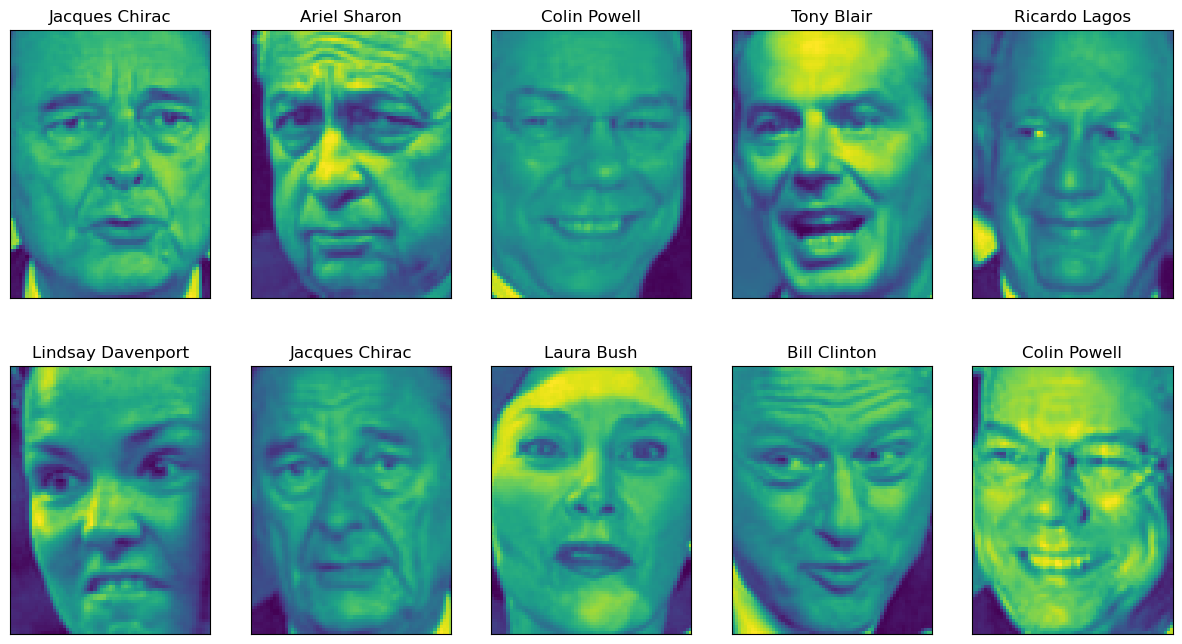

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(15, 8),
                         subplot_kw={'xticks': (), 'yticks': ()})

for target, image, ax in zip(people.target, people.images, axes.ravel()):
    ax.imshow(image)
    ax.set_title(people.target_names[target])

plt.show()

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    people.data,
    people.target,
    test_size=0.2,
    random_state=20
)

y_train = y_train.astype(int)
y_test = y_test.astype(int)

batch_size = len(X_train)

print(X_train.shape, y_train.shape, y_test.shape)
print("people.images.shape: {}".format(people.images.shape))
print("Number of classes: {}".format(len(people.target_names)))

(2029, 5655) (2029,) (508,)
people.images.shape: (2537, 87, 65)
Number of classes: 45


In [6]:
count = np.bincount(people.target)

for i, (count, name) in enumerate(zip(count, people.target_names)):
    print("{0:25} {1:3}".format(name, count), end=" ")
    
    if (i + 1) % 3 == 0:
        print()

Alejandro Toledo           39 Alvaro Uribe               35 Amelie Mauresmo            21 
Andre Agassi               36 Ariel Sharon               77 Atal Bihari Vajpayee       24 
Bill Clinton               29 Colin Powell              236 David Beckham              31 
Donald Rumsfeld           121 George Robertson           22 George W Bush             530 
Gerhard Schroeder         109 Gloria Macapagal Arroyo    44 Gray Davis                 26 
Hamid Karzai               22 Hans Blix                  39 Hugo Chavez                71 
Igor Ivanov                20 Jack Straw                 28 Jacques Chirac             52 
Jean Chretien              55 Jennifer Aniston           21 Jennifer Capriati          42 
Jennifer Lopez             21 John Ashcroft              53 Juan Carlos Ferrero        28 
Junichiro Koizumi          60 Kofi Annan                 32 Laura Bush                 41 
Lindsay Davenport          22 Lleyton Hewitt             41 Megawati Sukarnoputri      33 

In [9]:
mask = np.zeros(people.target.shape, dtype=np.bool_)

for target in np.unique(people.target):
    mask[np.where(people.target == target)[0][:50]] = True

X_people = people.data[mask]
y_people = people.target[mask]

X_people = X_people / 255.0

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_people,
    y_people,
    stratify=y_people,
    random_state=0
)

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)

print("Test set score of 1-nn: {:.2f}".format(
    knn.score(X_test, y_test)
))

Test set score of 1-nn: 0.28


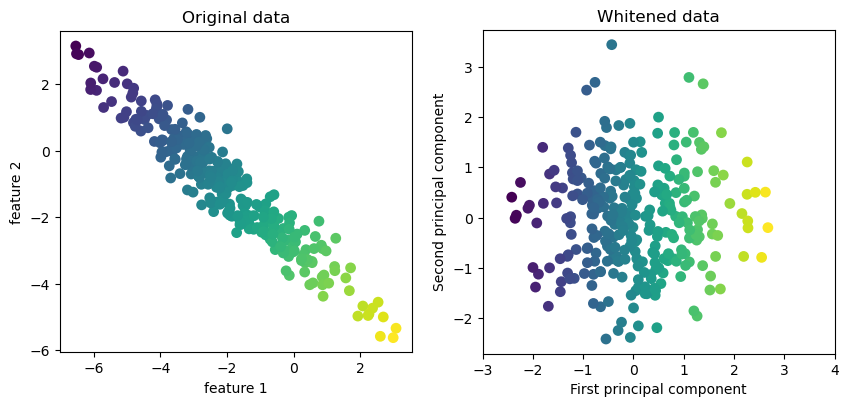

In [11]:
mglearn.plots.plot_pca_whitening()
plt.show()

In [12]:
pca = PCA(
    n_components=100,
    whiten=True,
    random_state=0
).fit(X_train)

X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

print("X_train_pca.shape: {}".format(X_train_pca.shape))

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train_pca, y_train)

print("Test set accuracy: {:.2f}".format(
    knn.score(X_test_pca, y_test)
))

print("pca.components_.shape: {}".format(
    pca.components_.shape
))

X_train_pca.shape: (1182, 100)
Test set accuracy: 0.33
pca.components_.shape: (100, 5655)


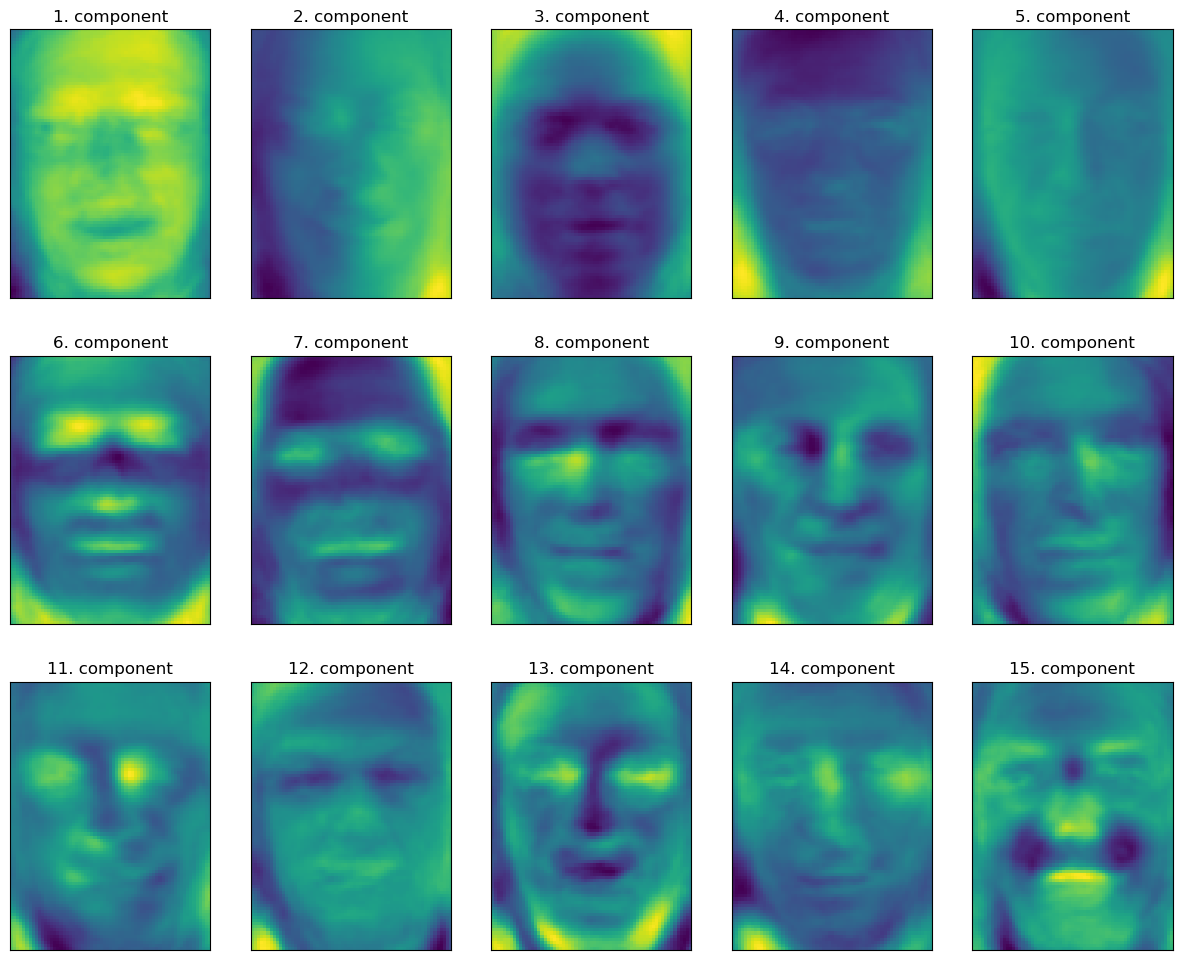

In [13]:
fig, axes = plt.subplots(
    3, 5,
    figsize=(15, 12),
    subplot_kw={'xticks': (), 'yticks': ()}
)

for i, (component, ax) in enumerate(
    zip(pca.components_, axes.ravel())
):
    ax.imshow(
        component.reshape(image_shape),
        cmap='viridis'
    )
    ax.set_title("{}. component".format(i + 1))

plt.show()

In [14]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train_pca)
X_test_scaled = scaler.transform(X_test_pca)

In [15]:
model = Sequential([
    Input(shape=(100,)),
    Dense(300, activation='relu'),
    Dense(100, activation='relu'),
    Dense(
        len(np.unique(y_train)),
        activation='softmax'
    )
])

In [16]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
history = model.fit(
    X_train_scaled,
    y_train,
    batch_size=50,
    epochs=20,
    shuffle=False,
    verbose=1
)

Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.0279 - loss: 3.8036
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0313 - loss: 3.7604
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0347 - loss: 3.7324
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0812 - loss: 3.7073
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1125 - loss: 3.6772
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1404 - loss: 3.6379
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1455 - loss: 3.5958
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1633 - loss: 3.5424
Epoch 9/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1844 - loss: 3.4738
Epoch 10/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2259 - loss: 3.3965
Epoch 11/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2335 - loss: 3.3009
Epoch 12/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2538 - lo

In [18]:
loss, accuracy = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=1
)

print("Test Accuracy:", accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3392 - loss: 2.6757
Test Accuracy: 0.33924052119255066
